In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
#
import os

for dirname, _, _ in os.walk('/kaggle/input'):
    if 'LA' in dirname:
        print(dirname)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_dev
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_dev/flac
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_train
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_train/flac
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_cm_protocols
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_eval
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_eval/flac
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_asv_protocols
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_asv_scores


# find protocol files 

In [2]:
import glob

protocols = glob.glob('/kaggle/input/**/*txt', recursive=True)

for p in protocols:
    print(p)

/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/README.LA.txt
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_dev/LICENSE.txt
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_train/LICENSE.txt
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_eval/LICENSE.txt
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.male.trn.txt
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.female.trn.txt
/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.

# read train protocol files

In [3]:
import pandas as pd

protocol_path = "/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"

df = pd.read_csv(protocol_path, sep=' ', header=None)

df.head()

,0,1,2,3,4
0,LA_0079,LA_T_1138215,-,-,bonafide
1,LA_0079,LA_T_1271820,-,-,bonafide
2,LA_0079,LA_T_1272637,-,-,bonafide
3,LA_0079,LA_T_1276960,-,-,bonafide
4,LA_0079,LA_T_1341447,-,-,bonafide


# extract filename and label 

In [4]:
metadata = df[[1, 4]]

metadata.columns = ['file', 'label']

metadata.head()

,file,label
0,LA_T_1138215,bonafide
1,LA_T_1271820,bonafide
2,LA_T_1272637,bonafide
3,LA_T_1276960,bonafide
4,LA_T_1341447,bonafide


# find audio files 

In [5]:
import glob

In [6]:
audio_files = glob.glob('/kaggle/input/**/*.flac', recursive=True)

print(audio_files[:5])

['/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_dev/flac/LA_D_5327408.flac', '/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_dev/flac/LA_D_8046653.flac', '/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_dev/flac/LA_D_4961527.flac', '/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_dev/flac/LA_D_2943983.flac', '/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_dev/flac/LA_D_6454007.flac']


# create full audio files

In [7]:
import pandas as pd

path = "/kaggle/input/datasets/hahunavth/asvspoof2019-la/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"

# Load with space separator and specific column names
metadata = pd.read_csv(path, sep=' ', header=None, names=['speaker', 'file', 'codec', 'source', 'label'])


metadata.head()

,speaker,file,codec,source,label
0,LA_0079,LA_T_1138215,-,-,bonafide
1,LA_0079,LA_T_1271820,-,-,bonafide
2,LA_0079,LA_T_1272637,-,-,bonafide
3,LA_0079,LA_T_1276960,-,-,bonafide
4,LA_0079,LA_T_1341447,-,-,bonafide


In [8]:
audio_dict = {}

for path in audio_files:
    filename = path.split('/')[-1].replace('.flac', '')
    audio_dict[filename] = path

metadata['path'] = metadata['file'].map(audio_dict)

metadata.head()

,speaker,file,codec,source,label,path
0,LA_0079,LA_T_1138215,-,-,bonafide,/kaggle/input/datasets/hahunavth/asvspoof2019-...
1,LA_0079,LA_T_1271820,-,-,bonafide,/kaggle/input/datasets/hahunavth/asvspoof2019-...
2,LA_0079,LA_T_1272637,-,-,bonafide,/kaggle/input/datasets/hahunavth/asvspoof2019-...
3,LA_0079,LA_T_1276960,-,-,bonafide,/kaggle/input/datasets/hahunavth/asvspoof2019-...
4,LA_0079,LA_T_1341447,-,-,bonafide,/kaggle/input/datasets/hahunavth/asvspoof2019-...


# load one audio file 

In [9]:
import librosa

sample_path = metadata.iloc[0]['path']

y, sr = librosa.load(sample_path, sr=16000)

print("Shape:", y.shape)
print("Sample Rate:", sr)

Shape: (55329,)
Sample Rate: 16000


# Extract MFCC Features

In [10]:
import numpy as np

def extract_features(file_path):
    
    y, sr = librosa.load(file_path, sr=16000)
    
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=40
    )
    
    mfcc_scaled = np.mean(mfcc.T, axis=0)
    
    return mfcc_scaled

In [11]:
sample_features = extract_features(metadata.iloc[0]['path'])

print(sample_features.shape)
print(sample_features)

(40,)
[-310.40796      43.036842    -18.052128      8.644585    -30.47272
   -6.5417266   -12.117187     -9.478478     -5.3997006   -17.2626
  -10.453364     -4.147436     -6.144251    -13.564544    -10.693901
   -5.905566     -6.24238       1.0447847    -2.2739139    -5.1314917
   -4.8957872    -2.922435     -7.694468     -1.7979811    -4.739685
   -3.9486907    -4.4956765    -5.681719     -6.271316     -3.7931628
   -1.5131791    -2.9168916    -5.67985      -2.0975857    -2.0209813
   -0.7483065    -1.5217468    -1.399886     -2.3311858     0.67622966]


# extract features for multiple audio files 

In [12]:
sample_df = metadata.sample(1000, random_state=42)

# creating featured dataset

In [13]:
features = []
labels = []

for index, row in sample_df.iterrows():
    
    try:
        feature = extract_features(row['path'])
        
        features.append(feature)
        labels.append(row['label'])
        
    except:
        pass
#converting into arrays 
X = np.array(features)
y = np.array(labels)

print(X.shape)
print(y.shape)

(1000, 40)
(1000,)


In [14]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(y_encoded[:5])

[1 1 1 1 1]


 # **training XGboost model**

In [29]:
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# train/test split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# SMOTE 

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
model.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

# make predictions

In [31]:
y_pred = model.predict(X_test)


# model evaluation

In [32]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.72      0.72      0.72        18
           1       0.97      0.97      0.97       182

    accuracy                           0.95       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.95      0.95      0.95       200



# confusion matrix 

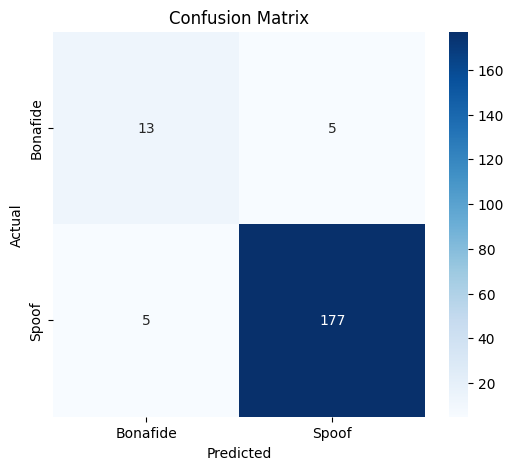

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bonafide', 'Spoof'],
    yticklabels=['Bonafide', 'Spoof']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# plot spectrogram

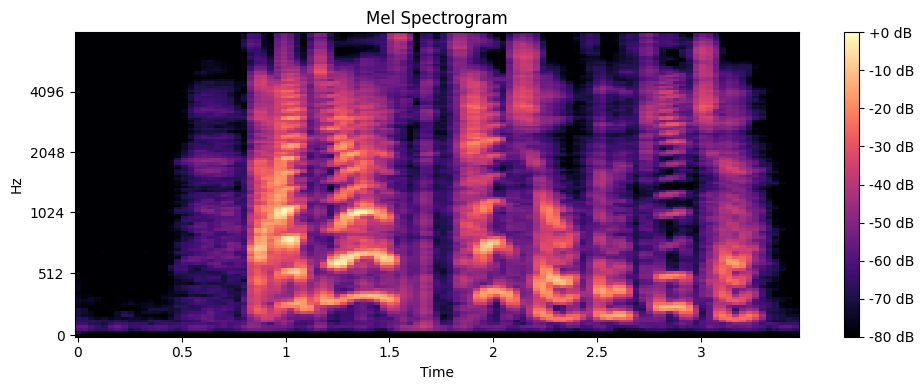

In [34]:
sample_path = metadata.iloc[0]['path']

y, sr = librosa.load(sample_path, sr=16000)

spectrogram = librosa.feature.melspectrogram(
    y=y,
    sr=sr
)

spectrogram_db = librosa.power_to_db(
    spectrogram,
    ref=np.max
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    spectrogram_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")

plt.tight_layout()
plt.show()

# plot mfcc heatmap

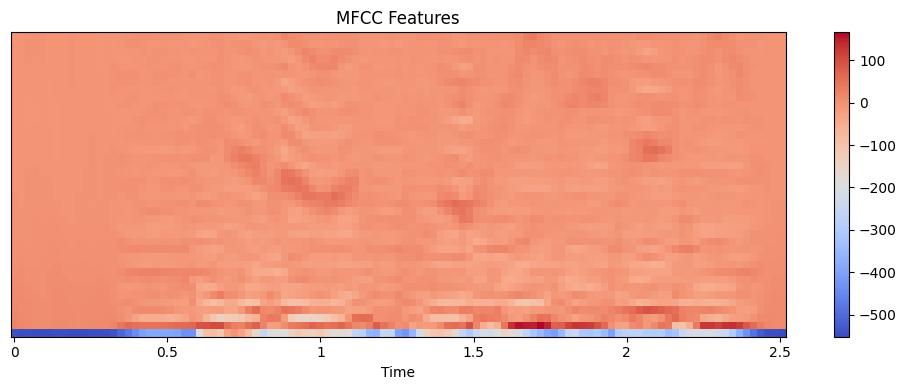

In [35]:
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=40
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()
plt.title("MFCC Features")

plt.tight_layout()
plt.show()

# comparing bonafide and spoof plot 

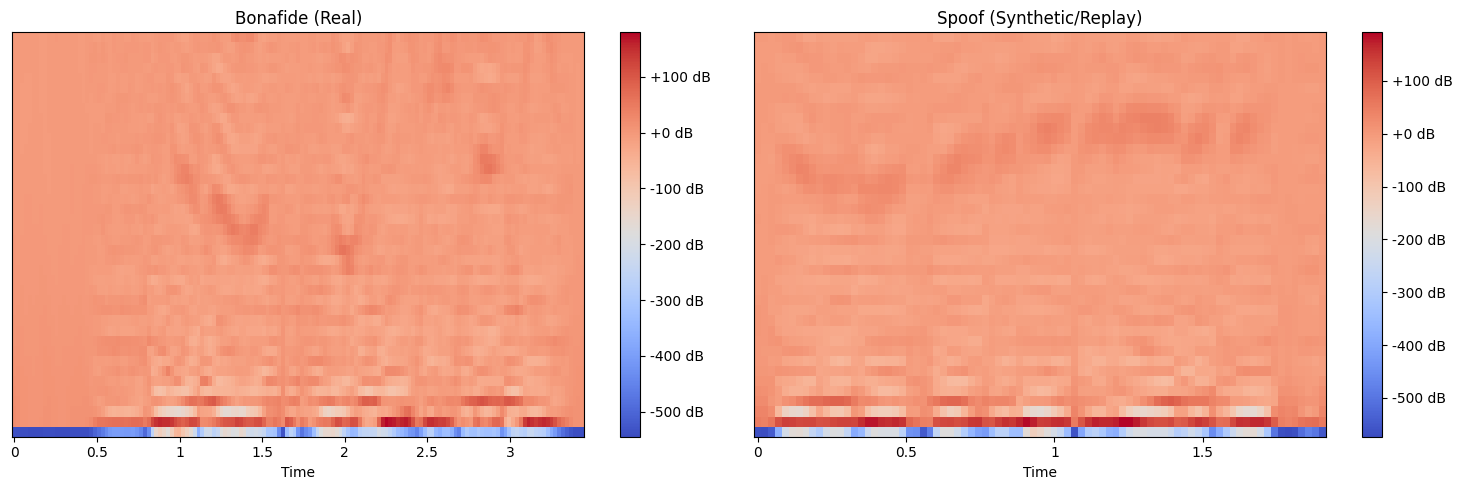

In [36]:
import librosa.display
import matplotlib.pyplot as plt

# 1. Grab one example of each
bonafide_path = metadata[metadata['label'] == 'bonafide']['path'].iloc[0]
spoof_path = metadata[metadata['label'] == 'spoof']['path'].iloc[0]

def plot_mfcc(path, title, subplot_pos):
    y, sr = librosa.load(path)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    
    plt.subplot(1, 2, subplot_pos)
    librosa.display.specshow(mfcc, x_axis='time')
    plt.title(title)
    plt.colorbar(format='%+2.0f dB')

plt.figure(figsize=(15, 5))
plot_mfcc(bonafide_path, "Bonafide (Real)", 1)
plot_mfcc(spoof_path, "Spoof (Synthetic/Replay)", 2)
plt.tight_layout()
plt.show()